# `09_ML.ipynb`
`uv add scikit-learn pandas matplotlib`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')

In [2]:
# 도미
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]
# 빙어
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

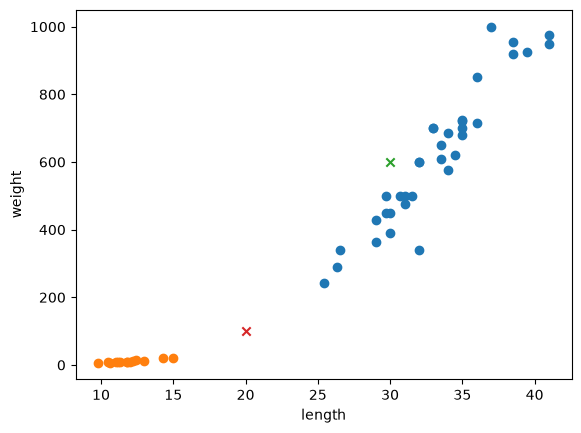

In [12]:
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)

plt.scatter([30], [600], marker='x')
plt.scatter([20], [100], marker='x')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

## KNN (K-Nearest Neighbors) 분류

In [4]:
# 도미 데이터프레임(표)
bream_df = pd.DataFrame({
    'l': bream_length,
    'w': bream_weight,
    'c': [1] * len(bream_length)  # 카테고리1: 도미
})

# 빙어 데이터프레임(표)
smelt_df = pd.DataFrame({
    'l': smelt_length,
    'w': smelt_weight,
    'c': [0] * len(smelt_length)  # 카테고리0: 빙어
})

# 최종 데이터 프레임
df = pd.concat([bream_df, smelt_df], ignore_index=True)

# df의 앞 5개 row만 보기
df.head()

,l,w,c
0,25.4,242.0,1
1,26.3,290.0,1
2,26.5,340.0,1
3,29.0,363.0,1
4,29.0,430.0,1


In [10]:
# df 에 들어있는 데이터(생선의 길이, 무게, 종류)를 학습시킴

from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()
# 원본df의 특정 컬럼만 뽑은것
X = df[['l', 'w']]
y = df['c']

# fit=학습. X는 데이터, y는 답
_ = kn.fit(X, y)

In [11]:
kn.score(X, y)

1.0

In [13]:
kn.predict([
    [30, 600],  # 1번 케이스 -> c: 1 -> 도미
    [20, 100],  # 2번 케이스 -> c: 0 -> 빙어
])

array([1, 0])

In [24]:
# 문제 1 -> K의 개수가 커지면? (현재 전체 데이터 개수 49)
kn49 = KNeighborsClassifier(n_neighbors=49)
_ = kn49.fit(X, y)  # 무조건 도미로 판단하는 분류기
kn49.score(X, y)  # 0.74xxx -> 35/49

# 현재 도미 35, 빙어 14
kn49.predict([
    [1, 1],
    [1000, 1000]
])

array([1, 1])

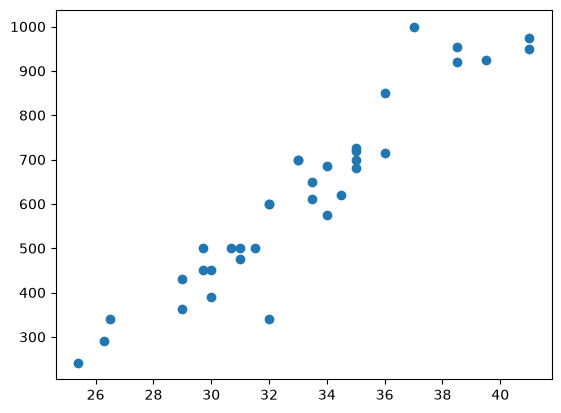

In [68]:
# 도미 데이터로만 훈련
train_X = df[:35][['l', 'w']]
train_y = df[:35]['c']

# 테스트는 빙어만 나옴
test_X = df[35:][['l', 'w']]
test_y = df[35:]['c']

kn = KNeighborsClassifier()
kn.fit(train_X, train_y)  # fit == 훈련
kn.score(test_X, test_y)  # score == 시험점수

plt.scatter(train_X['l'], train_X['w'])

In [70]:
from sklearn.model_selection import train_test_split

# 랜덤하게 train-set, test-set 나누기
train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=42)

# 최신모델
kn = KNeighborsClassifier()
kn.fit(train_X, train_y)  # 훈련셋으로만 훈련
kn.score(test_X, test_y)  # 테스트셋으로만 점수

1.0

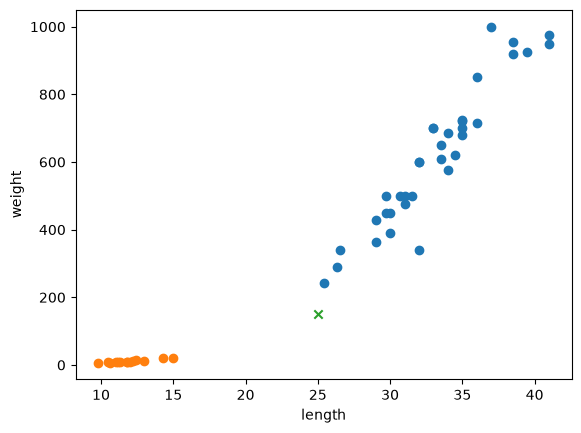

In [71]:
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
# 길이 25, 무게 150
plt.scatter([25], [150], marker='x')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [72]:
# 길이 25, 무게 150은 뭐야?
kn.predict([[25, 150]])  # 0 빙어? 이게 맞음?
# 야 25, 150의 최근접 이웃들을 보여줘
distances, ids = kn.kneighbors([[25, 150]])

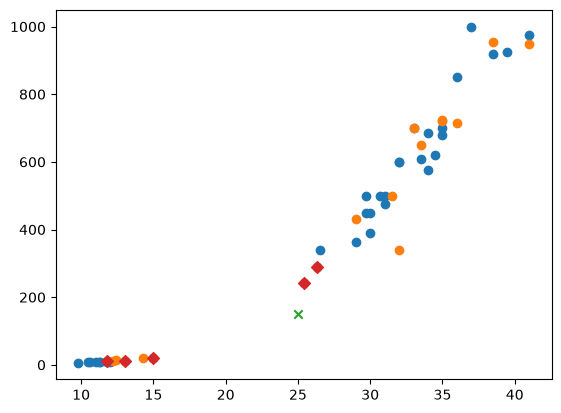

In [84]:
# 이웃들만 표시해서 보자
plt.scatter(train_X['l'], train_X['w'])  # 파란색 -> 훈련데이터
plt.scatter(test_X['l'], test_X['w'])    # 주황색 -> 테스트데이터 
plt.scatter([25], [150], marker='x')     # 분류하려고 하는 데이터
plt.scatter(train_X.iloc[ids[0]]['l'], train_X.iloc[ids[0]]['w'], marker='D')  # 모델 판단, 최근접 5개

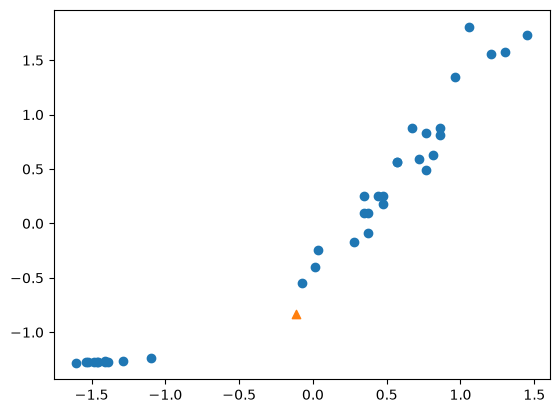

In [ ]:
# z점수 (표준점수)
import numpy as np

# 평균
mean = np.mean(train_X, axis=0)
# 표준편차
std = np.std(train_X, axis=0)
# z 점수 (-3 ~ 3) -> 이걸 벗어나면 특이값
scaled_X = (train_X - mean) / std

new = ([25, 150] - mean) / std
plt.scatter(scaled_X[:]['l'], scaled_X[:]['w'])
plt.scatter(new['l'], new['w'], marker='^')

In [101]:
# z-score 로 바꾸고 학습
kn.fit(scaled_X, train_y)
test_scaled_X = (test_X - mean) / std
kn.score(test_scaled_X, test_y)

1.0

In [ ]:
# z-score 로 학습된 모델로, 새로운 생선 예측 -> 도미
kn.predict([new])

array([1])

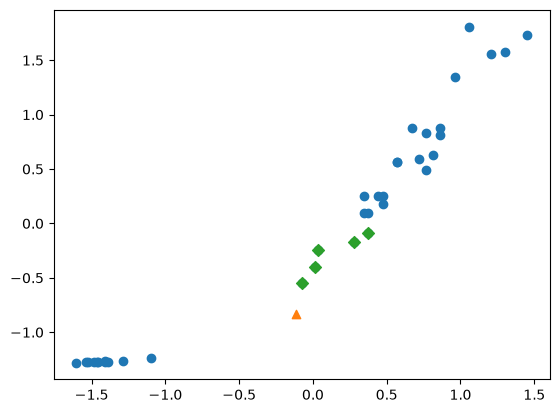

In [ ]:
# 실제 새로운 생선의 최근접 이웃 표시
dist, indexes = kn.kneighbors([new])
plt.scatter(scaled_X[:]['l'], scaled_X[:]['w'])
plt.scatter(new['l'], new['w'], marker='^')
plt.scatter(scaled_X.iloc[indexes[0]]['l'], scaled_X.iloc[indexes[0]]['w'], marker='D')
plt.show()

## 회귀 (Regression) == 값을 예측

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 농어의 길이 & 무게
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])


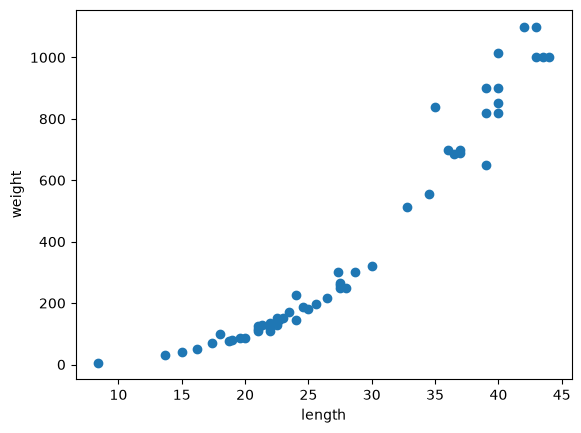

In [107]:
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(perch_length, perch_weight, random_state=42)

# X자리에는 벡터가 아닌 매트릭스가 와야함
X_train = X_train.reshape(-1, 1)  # 벡터 -> 매트릭스 변환
X_test = X_test.reshape(-1, 1)

In [114]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()
knr.fit(X_train, y_train)

knr.score(X_test, y_test)

0.992809406101064

In [120]:
# 우리 모델이 예측한 값
test_prediction = knr.predict(X_test)

# 예측 과 정답의 오차
test_prediction - y_test

array([ 54.1, -20.4,  -2. ,  -8. ,   6. ,  27. ,  -8.6,  -4.6, -53. ,
       -12. ,  10. ,   8.5,  -2. , -52. ])

In [ ]:
# 훈련시킨 데이터로 다시 테스트를 돌려보자
knr.score(X_train, y_train)

0.9698823289099254

In [ ]:
# 과대적합 Overfitting -> 훈련셋에 너무 절여졌다
# 훈련 점수 >> 테스트 점수 -

# 과소적합 Underfitting -> 잘못됨
# 훈련 점수 << 테스트 점수 or 걍 전체적으로 점수가 낮음

In [131]:
knr.n_neighbors = 3

knr.fit(X_train, y_train)
print('테스트:' ,knr.score(X_test, y_test))
print('훈련: ', knr.score(X_train, y_train))

테스트: 0.9746459963987609
훈련:  0.9804899950518966


In [138]:
# k=3 인 최근접 예측기로 길이 50 농어의 무게를 예측
knr.predict([[50]])

array([1033.33333333])

[1033.33333333]


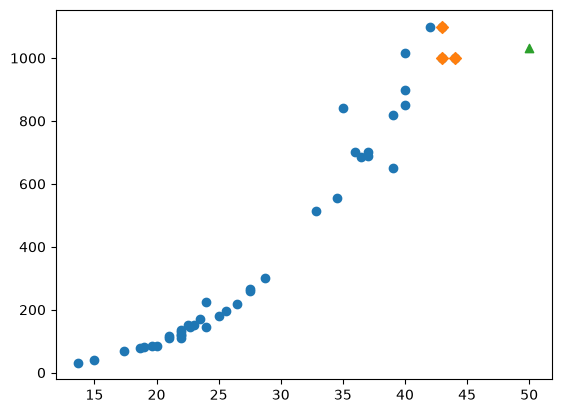

In [139]:
print(knr.predict([[50]]))
distances, indexes = knr.kneighbors([[50]])

plt.scatter(X_train, y_train)
plt.scatter(X_train[indexes], y_train[indexes], marker='D')
plt.scatter(50, 1033, marker='^')
plt.show()

### 선형 회귀 (Linear Regression)

In [145]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

# 기울기,  절편
print('기울기, 절편', lr.coef_, lr.intercept_)

# Train > Test 긴 하지만, 전체적으로 낮아서 -> Underfitting
print('Train', lr.score(X_train, y_train))
print('Test', lr.score(X_test, y_test))
# 50길이 농어의 무게?
lr.predict([[50]])

기울기, 절편 [39.01714496] -709.0186449535474
Train 0.9398463339976041
Test 0.824750312331356


array([1241.83860323])

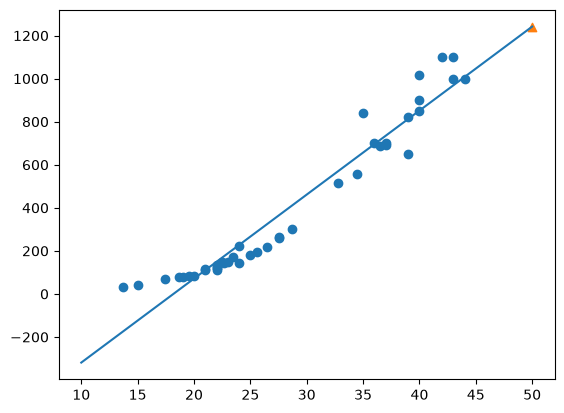

In [ ]:
plt.scatter(X_train, y_train)
plt.plot([10, 50], [10*lr.coef_ + lr.intercept_, 50*lr.coef_ + lr.intercept_])
plt.scatter(50, 1241.8, marker='^')
plt.show()

In [180]:
import numpy as np
# ax + b 는 직선밖에 안나옴
# ax^2 + bx + c 로 가자

X = np.array(perch_length).reshape(-1, 1)
X2 = np.column_stack([X**2, X])

y = np.array(perch_weight)

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, random_state=42)

In [190]:
lr2 = LinearRegression()
lr2.fit(X2_train, y_train)

print(lr2.coef_, lr2.intercept_)

# 2차 방정식으로 예측한 50길이 의 결과
lr2.predict([[50**2, 50]])

print('훈련점수', lr2.score(X2_train, y_train))
print('테스트점수', lr2.score(X2_test, y_test))

[  1.01433211 -21.55792498] 116.0502107827827
훈련점수 0.9706807451768623
테스트점수 0.9775935108325122


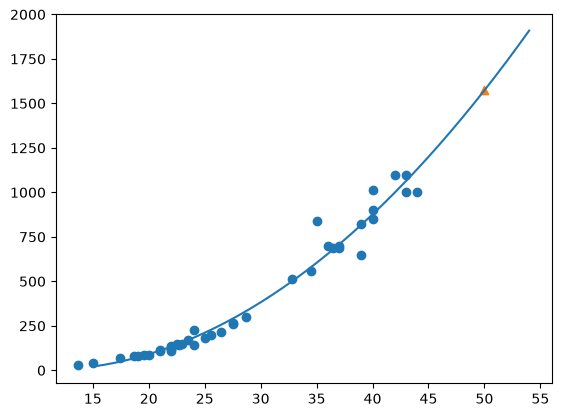

In [189]:
point = np.arange(15, 55)
plt.scatter(X_train, y_train)
plt.plot(point, 1.014*point**2 - 21.55*point + 116.05)
plt.scatter(50, 1573, marker='^')
plt.show()

In [193]:
X = np.array(perch_length).reshape(-1, 1)
X3 = np.column_stack([X**3, X**2, X])

y = np.array(perch_weight)

X3_train, X3_test, y_train, y_test = train_test_split(X3, y, random_state=42)

In [ ]:
lr3 = LinearRegression()
lr3.fit(X3_train, y_train)

print(lr3.coef_, lr3.intercept_)
    
# 2차 방정식으로 예측한 50길이 의 결과
print(lr3.predict([[50**3, 50**2, 50]]))

print('훈련점수', lr3.score(X3_train, y_train))
print('테스트점수', lr3.score(X3_test, y_test))

[-2.93594164e-02  3.54762430e+00 -9.05932876e+01] 709.9479507456633
[1379.41727785]
훈련점수 0.9729178478354534
테스트점수 0.958836372742297


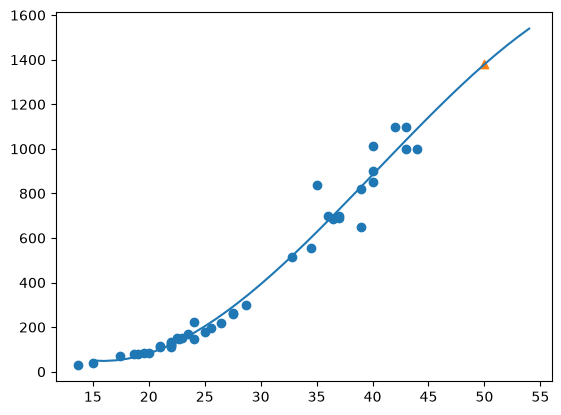

In [198]:
point = np.arange(15, 55)
plt.scatter(X_train, y_train)
plt.plot(point, lr3.coef_[0]*point**3 + lr3.coef_[1]*point**2 + lr3.coef_[2]*point + lr3.intercept_)
plt.scatter(50, 1379.41727785, marker='^')
plt.show()

In [199]:
print(f'''요약
1차 훈련: {lr.score(X_train, y_train)}
1차 테스트 {lr.score(X_test, y_test)}

2차 훈련: {lr2.score(X2_train, y_train)}
2차 테스트 {lr2.score(X2_test, y_test)}

3차 훈련: {lr3.score(X3_train, y_train)}
3차 테스트 {lr3.score(X3_test, y_test)}

무조건 제곱을 늘린다고 점수가 올라가지 않음
많이 올리면 과대적합 (훈련점수 > 테스트점수)이 일어날 확률 높음
''')


요약
1차 훈련: 0.9398463339976041
1차 테스트 0.824750312331356

2차 훈련: 0.9706807451768623
2차 테스트 0.9775935108325122

3차 훈련: 0.9729178478354534
3차 테스트 0.958836372742297

무조건 제곱을 늘린다고 점수가 올라가지 않음
많이 올리면 과대적합 (훈련점수 > 테스트점수)이 일어날 확률 높음



In [234]:
import numpy as np
import pandas as pd


# csv 파일 보려면 주소로 이동 (생선의 length, height, width 있음)
df = pd.read_csv('https://gist.githubusercontent.com/verba-neo/7e249412b0d4627fff28bc52a0518033/raw/fdfb820fe909f5f23b0f6252d7e6d18cfe58a906/gistfile1.txt')
perch_data = df.to_numpy()

perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

df.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [235]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(perch_data, perch_weight, random_state=42)

In [236]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.coef_, lr.intercept_)
print('---------다항식--------')
print(f'{round(lr.coef_[0], 2)} * 길이 + {round(lr.coef_[1], 2)} * 높이 + {round(lr.coef_[2], 2)} * 두께 + ({lr.intercept_})')
print('---------점수--------')
print(lr.score(X_train, y_train))
print(lr.score(X_test, y_test))

[ 9.07538153 69.46401443 38.00385678] -599.1708082981097
---------다항식--------
9.08 * 길이 + 69.46 * 높이 + 38.0 * 두께 + (-599.1708082981097)
---------점수--------
0.9559326821885706
0.8796419177546367


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# 각 특성들을 비비기 -> l, w, h, lw, lh, wh, l^2, w^2, h^2
# 이유? 자세한 개념은 다항회귀와 다항특성엔지니어링 검색
poly = PolynomialFeatures(degree=2, include_bias=False)  # 2차 (제곱)으로 부풀림
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

print('기존컬럼 개수: ', X_train.shape[1])
print('현재컬럼 개수: ', X_train_poly.shape[1])

기존컬럼 개수:  3
현재컬럼 개수:  9


In [ ]:
lr_p = LinearRegression()
lr_p.fit(X_train_poly, y_train)

print('점수 (이전과 비교)')
print(lr_p.score(X_train_poly, y_train))
print(lr_p.score(X_test_poly, y_test))

점수 (이전과 비교)
0.9903183436982126
0.9714559911594125
